# Section 3: Performance Metrics

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

from constants import *
from preprocessing import load_house_df

import warnings
warnings.filterwarnings("ignore")

set_project_theme()
pd.set_option("display.width", 120)
%matplotlib inline

In [2]:
house_df = load_house_df()
house_df.head()

,international,age,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades,should_recieve_housing,HO,A1,A2,A3,A4,grades_raw,grade_format,international_bin,age_group
0,domestic,26,2,31.1,62.93,5.8,46.488294,1,1,0,1,0,0,4.34,numeric_0_10,0,25 or older
1,domestic,27,5,13.2,66.45,5.9,61.705686,1,1,0,1,1,0,4.83,numeric_0_10,0,25 or older
2,domestic,25,5,9.8,50.23,5.2,50.063158,1,0,0,0,0,0,NaN,missing,0,25 or older
3,domestic,21,2,20.2,56.99,5.7,3.631151,1,1,0,0,1,0,2.06,numeric_0_10,0,under 25
4,domestic,34,7,51.9,32.31,4.6,43.430483,0,0,0,0,0,0,4.24,numeric_0_10,0,25 or older


In [3]:
target = house_df['should_recieve_housing']

for dm in decision_makers:
    acc = accuracy_score(target, house_df[dm])
    rec = recall_score(target, house_df[dm])
    prec = precision_score(target, house_df[dm])
    f1 = f1_score(target, house_df[dm])
    cf = confusion_matrix(target, house_df[dm])

    print(f'\n----{dm}----')
    print(f'Accuracy: {round(acc, 3)}')
    print(f'Recall: {round(rec, 3)}')
    print(f'Precision: {round(prec, 3)}')
    print(f'F1 Score: {round(f1, 3)}')
    print(f'Confusion Matrix:\n', cf)


----HO----
Accuracy: 0.864
Recall: 0.834
Precision: 0.789
F1 Score: 0.811
Confusion Matrix:
 [[1430  195]
 [ 145  730]]

----A1----
Accuracy: 0.788
Recall: 0.575
Precision: 0.76
F1 Score: 0.655
Confusion Matrix:
 [[1466  159]
 [ 372  503]]

----A2----
Accuracy: 0.808
Recall: 0.793
Precision: 0.698
F1 Score: 0.743
Confusion Matrix:
 [[1325  300]
 [ 181  694]]

----A3----
Accuracy: 0.828
Recall: 0.671
Precision: 0.804
F1 Score: 0.731
Confusion Matrix:
 [[1482  143]
 [ 288  587]]

----A4----
Accuracy: 0.848
Recall: 0.655
Precision: 0.879
F1 Score: 0.75
Confusion Matrix:
 [[1546   79]
 [ 302  573]]


### The same results in one table

The printout above is fine for checking single values, but for the report it is easier to read everything in one
place. We also add the counts of false negatives and false positives, the two error rates, and the share of
applicants each method selects, because these are the numbers we actually need when we discuss which metric fits
this situation.

In [4]:
metric_rows = []
for dm in decision_makers:
    pred = house_df[dm]
    tn, fp, fn, tp = confusion_matrix(target, pred).ravel()

    metric_rows.append({
        'Method': dm,
        'Accuracy': accuracy_score(target, pred),
        'Precision': precision_score(target, pred),
        'Recall': recall_score(target, pred),
        'F1': f1_score(target, pred),
        'Selection rate': pred.mean(),
        'FN (missed students)': fn,
        'FP (wrongly housed)': fp,
        'FNR': fn / (fn + tp),
        'FPR': fp / (fp + tn),
    })

metrics_df = pd.DataFrame(metric_rows).set_index('Method').round(3)
metrics_df

,Accuracy,Precision,Recall,F1,Selection rate,FN (missed students),FP (wrongly housed),FNR,FPR
Method,,,,,,,,,
HO,0.864,0.789,0.834,0.811,0.370,145,195,0.166,0.120
A1,0.788,0.760,0.575,0.655,0.265,372,159,0.425,0.098
A2,0.808,0.698,0.793,0.743,0.398,181,300,0.207,0.185
A3,0.828,0.804,0.671,0.731,0.292,288,143,0.329,0.088
A4,0.848,0.879,0.655,0.750,0.261,302,79,0.345,0.049


In [5]:
# A method that always says no would already reach this accuracy, so accuracy needs a reference point.
majority_baseline = 1 - target.mean()
print('Share of applicants who should receive housing:', round(target.mean(), 3))
print('Accuracy of a method that never allocates housing:', round(majority_baseline, 3))

Share of applicants who should receive housing: 0.35
Accuracy of a method that never allocates housing: 0.65


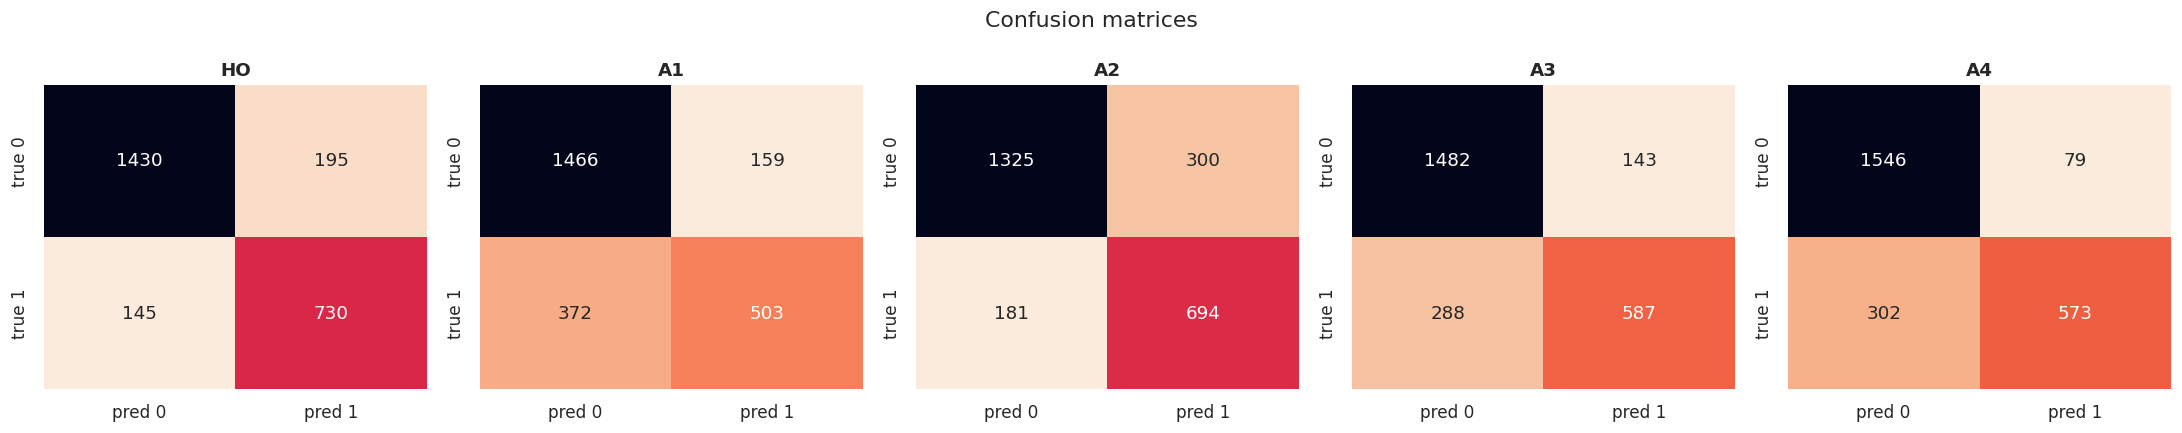

In [6]:
fig, axes = plt.subplots(1, len(decision_makers), figsize=(4 * len(decision_makers), 4))

for ax, dm in zip(axes, decision_makers):
    cf = confusion_matrix(target, house_df[dm])
    sns.heatmap(cf, annot=True, fmt='d', cmap=SEQUENTIAL_CMAP, cbar=False, ax=ax,
                xticklabels=['pred 0', 'pred 1'], yticklabels=['true 0', 'true 1'])
    ax.set_title(dm)

plt.suptitle('Confusion matrices')
plt.tight_layout()
plt.show()

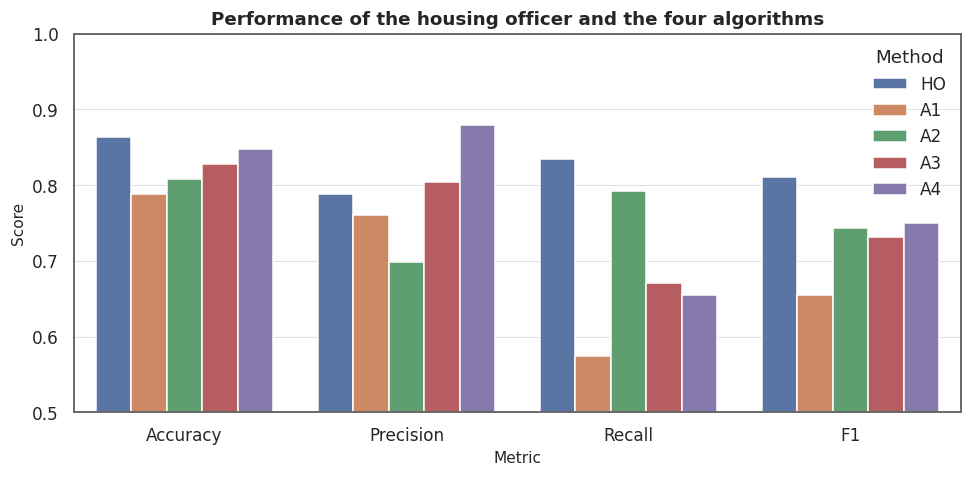

In [7]:
plot_df = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1']].reset_index().melt(
    id_vars='Method', var_name='Metric', value_name='Score')

plt.figure(figsize=(9, 4.5))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Method')
plt.ylim(0.5, 1.0)
plt.title('Performance of the housing officer and the four algorithms')
plt.tight_layout()
plt.show()

### Reading the results

As we could expect from the correlation between the target and the decision makers, HO has the best accuracy
(0.864) and the best recall (0.834).

After that A4 has the second best accuracy (0.848) and the best precision of all the methods (0.879). Precision
means that among the students A4 selected, 88 percent really should receive housing, which is the cleanest
selection of the five. But A4 pays for this with recall, it only finds 66 percent of the students who should
receive housing and misses 302 of them.

For recall the second place is for A2 (0.793), which makes sense because A2 is also the method that allocates
housing to the largest share of applicants (40 percent against 35 percent in the target). When you say yes more
often you catch more of the positive cases, but you also make many more false positives, 300 for A2 against 79
for A4.

A1 is the weakest on almost everything, with a recall of only 0.575, so it misses 372 students who should have
received housing.

At the end of the day, if we consider F1 as a metric which combines both recall and precision, we can suggest HO
first (0.811), then A4 (0.750).

### Which metric is the most appropriate here?

**Accuracy is the least useful of the four.** Only 35 percent of the applicants should receive housing, so a
method that simply refuses everybody would already score 0.65. All five methods beat that, but the gap is smaller
than the raw numbers suggest, and accuracy also treats the two error types as if they were the same mistake. They
are not.

**The two errors have very different consequences.** A false negative is a student who needs housing and does not
get it, and this student may end up with a very long commute, unaffordable rent, or dropping out. A false positive
is a unit given to somebody who needed it less, which is unfair and wastes a scarce unit, but it does not leave
anybody without a place to live. Since the harm of a false negative falls on the person who was already in the
weakest position, we consider recall the more important of the two.

**But precision cannot be ignored either**, because the number of housing units is limited. This is the detail
that makes this scenario different from a normal screening problem. We cannot simply lower the threshold and give
housing to everybody to maximise recall, since every wrongly allocated unit is a unit that a student in real need
cannot get. In other words the false positives here turn into extra false negatives in the real world, even though
the confusion matrix does not show it.

**So our answer is that F1 is the most appropriate single metric of the four**, since it forces a method to be
good on both sides at once, and we would look at recall as the tie breaker when two methods have a similar F1. If
the university could say how many units it actually has, an even better approach would be to fix the number of
allocations to the capacity and compare the methods at that fixed selection rate, because right now A2 and A4
select 40 and 26 percent of the applicants, which are not comparable situations.

**Based on these scores alone we would recommend the housing officer.** HO has the best F1, the best recall and
the best accuracy at the same time, and it is not a close call, the gap to A4 is 6 percentage points of F1. Among
the algorithms we would pick A4 if the university values precision and A2 if it values recall.

We should be careful with the word "recommend" though. All of these numbers only measure agreement with
`should_recieve_housing`, and as we saw in the data analysis this target is built almost entirely on two scores
that the university itself produced, and it is strongly connected to age. A method can agree with that target
perfectly and still be unfair, which is exactly why we go on to the fairness sections instead of stopping here.

In [8]:
metrics_df.to_csv(RESULTS_DIR / 'performance_metrics.csv')